# Selecting Multiple Landsat Images for Para, Brazil

In [1]:
from pystac_client import Client
import geopandas as gpd
import matplotlib.pyplot as plt
import rioxarray as rxr
import xarray as xr
from pathlib import Path
from rasterio.enums import Resampling

## Exploring Element 84's Earth Science Catalogue
### Connecting to the API

In [2]:
client = Client.open('https://earth-search.aws.element84.com/v1')

### Printing Collection Names

In [3]:
collections = client.get_collections()

for i in collections:
    print(i.id)

sentinel-2-pre-c1-l2a
cop-dem-glo-30
naip
cop-dem-glo-90
landsat-c2-l2
sentinel-2-l2a
sentinel-2-l1c
sentinel-2-c1-l2a
sentinel-1-grd


## Creating the Para Geometry
### Inspecting the Para GeoDataFrame

In [4]:
para = gpd.read_file('../data/vectors/para.gpkg')
para.shape

(1, 8)

In [5]:
print(para.crs)

EPSG:4674


In [6]:
para = para.to_crs('EPSG:4326')
para.head(1)

,CD_UF,NM_UF,SIGLA_UF,CD_REGIA,NM_REGIA,SIGLA_RG,AREA_KM2,geometry
0,15,Pará,PA,1,Norte,N,1245828.829,"MULTIPOLYGON (((-50.84599 -9.80064, -51.05801 ..."


### Creating the Para Extents Geometry

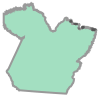

In [7]:
para_geom = para['geometry'].iloc[0]
para_geom

## Retrieving Landsat Data
### Creating the Search Query

In [8]:
search = client.search(
    collections=['landsat-c2-l2'],
    intersects=para_geom,
    datetime='2024-01-01/2024-12-31',
)
items = list(search.items())

print(f'Found {len(items)} items')

Found 3287 items


### Creating a GeoDataFrame

In [9]:
total_ids = gpd.GeoDataFrame.from_features(items, crs='EPSG:4326')
total_ids.shape

(3287, 29)

In [10]:
total_ids.columns

Index(['geometry', 'platform', 'instruments', 'created', 'gsd', 'description',
       'eo:cloud_cover', 'view:off_nadir', 'view:sun_elevation',
       'view:sun_azimuth', 'proj:shape', 'proj:transform', 'proj:centroid',
       'landsat:cloud_cover_land', 'landsat:wrs_type', 'landsat:wrs_path',
       'landsat:wrs_row', 'landsat:collection_category',
       'landsat:collection_number', 'landsat:correction', 'landsat:scene_id',
       'landsat:product_generated', 'grid:code', 'sci:doi', 'datetime',
       'earthsearch:payload_id', 'processing:software', 'updated',
       'proj:code'],
      dtype='object')

In [11]:
total_ids['id'] = [item.id for item in items]
total_ids.head(1)

,geometry,platform,instruments,created,gsd,description,eo:cloud_cover,view:off_nadir,view:sun_elevation,view:sun_azimuth,...,landsat:scene_id,landsat:product_generated,grid:code,sci:doi,datetime,earthsearch:payload_id,processing:software,updated,proj:code,id
0,"POLYGON ((-51.93531 -9.08177, -52.31617 -10.81...",landsat-9,"[oli, tirs]",2025-01-02T02:42:32.617Z,30,Landsat Collection 2 Level-2,90.61,0,59.309376,118.55105,...,LC92240672024366LGN00,2025-01-02T02:00:17Z,WRS2-224067,10.5066/P9OGBGM6,2024-12-31T13:31:47.413259Z,usgs-landsat-c2l2/workflow-landsat-to-stac/bef...,{'landsat-to-stac': 'v2023.11.16'},2025-01-02T02:42:32.617Z,EPSG:32622,LC09_L2SP_224067_20241231_02_T2


### Filtering Landsat 8 and 9 Images

In [12]:
total_ids = total_ids[
    total_ids['landsat:scene_id'].str.match(r'^LC[89]')
]

### Filtering by Cloud Cover

In [13]:
lowest_cloud = total_ids.sort_values('eo:cloud_cover').groupby('grid:code', as_index=False).head(1)
lowest_cloud

,geometry,platform,instruments,created,gsd,description,eo:cloud_cover,view:off_nadir,view:sun_elevation,view:sun_azimuth,...,landsat:scene_id,landsat:product_generated,grid:code,sci:doi,datetime,earthsearch:payload_id,processing:software,updated,proj:code,id
1704,"POLYGON ((-56.58345 -9.08029, -56.96437 -10.81...",landsat-8,"[oli, tirs]",2024-07-06T05:15:53.650Z,30,Landsat Collection 2 Level-2,0.00,0,46.084975,39.837255,...,LC82270672024171LGN00,2024-07-06T04:32:32Z,WRS2-227067,10.5066/P9OGBGM6,2024-06-19T13:49:24.619890Z,usgs-landsat-c2l2/workflow-landsat-to-stac/0c2...,{'landsat-to-stac': 'v2023.11.16'},2024-07-06T05:15:53.650Z,EPSG:32621,LC08_L2SP_227067_20240619_02_T1
1292,"POLYGON ((-58.13621 -9.08174, -58.51756 -10.81...",landsat-9,"[oli, tirs]",2024-08-06T12:25:51.562Z,30,Landsat Collection 2 Level-2,0.00,0,49.975599,48.137342,...,LC92280672024218LGN00,2024-08-06T11:54:14Z,WRS2-228067,10.5066/P9OGBGM6,2024-08-05T13:55:54.265566Z,usgs-landsat-c2l2/workflow-landsat-to-stac/7b3...,{'landsat-to-stac': 'v2023.11.16'},2024-08-06T12:25:51.562Z,EPSG:32621,LC09_L2SP_228067_20240805_02_T1
1680,"POLYGON ((-51.60061 -7.63674, -51.97787 -9.369...",landsat-9,"[oli, tirs]",2024-06-23T11:52:39.614Z,30,Landsat Collection 2 Level-2,0.00,0,47.216646,40.792711,...,LC92240662024174LGN00,2024-06-23T11:34:52Z,WRS2-224066,10.5066/P9OGBGM6,2024-06-22T13:30:18.286999Z,usgs-landsat-c2l2/workflow-landsat-to-stac/ba4...,{'landsat-to-stac': 'v2023.11.16'},2024-06-23T11:52:39.614Z,EPSG:32622,LC09_L2SP_224066_20240622_02_T1
1275,"POLYGON ((-55.03971 -9.08123, -55.42108 -10.81...",landsat-9,"[oli, tirs]",2024-08-08T15:17:15.122Z,30,Landsat Collection 2 Level-2,0.00,0,50.378905,48.742798,...,LC92260672024220LGN00,2024-08-08T11:14:21Z,WRS2-226067,10.5066/P9OGBGM6,2024-08-07T13:43:32.326404Z,usgs-landsat-c2l2/workflow-landsat-to-stac/0d6...,{'landsat-to-stac': 'v2023.11.16'},2024-08-08T15:17:15.122Z,EPSG:32621,LC09_L2SP_226067_20240807_02_T1
1276,"POLYGON ((-54.72427 -7.63631, -55.10257 -9.368...",landsat-9,"[oli, tirs]",2024-08-08T15:16:26.821Z,30,Landsat Collection 2 Level-2,0.00,0,51.480788,49.888905,...,LC92260662024220LGN00,2024-08-08T11:14:38Z,WRS2-226066,10.5066/P9OGBGM6,2024-08-07T13:43:08.401500Z,usgs-landsat-c2l2/workflow-landsat-to-stac/b27...,{'landsat-to-stac': 'v2023.11.16'},2024-08-08T15:16:26.821Z,EPSG:32621,LC09_L2SP_226066_20240807_02_T1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
791,"POLYGON ((-52.84303 1.04347, -53.21147 -0.6917...",landsat-8,"[oli, tirs]",2024-10-06T06:11:08.740Z,30,Landsat Collection 2 Level-2,5.63,0,65.492795,99.444379,...,LC82260602024276LGN00,2024-10-06T03:35:40Z,WRS2-226060,10.5066/P9OGBGM6,2024-10-02T13:41:05.439896Z,usgs-landsat-c2l2/workflow-landsat-to-stac/3b8...,{'landsat-to-stac': 'v2023.11.16'},2024-10-06T06:11:08.740Z,EPSG:32622,LC08_L2SP_226060_20241002_02_T1
1457,"POLYGON ((-47.01226 -0.40457, -47.38213 -2.139...",landsat-8,"[oli, tirs]",2024-07-23T04:56:47.184Z,30,Landsat Collection 2 Level-2,6.02,0,54.022645,50.099603,...,LC82220612024200LGN00,2024-07-23T04:37:06Z,WRS2-222061,10.5066/P9OGBGM6,2024-07-18T13:16:27.909691Z,usgs-landsat-c2l2/workflow-landsat-to-stac/0a8...,{'landsat-to-stac': 'v2023.11.16'},2024-07-23T04:56:47.184Z,EPSG:32623,LC08_L2SP_222061_20240718_02_T1
1525,"POLYGON ((-47.95583 -4.74462, -48.33033 -6.478...",landsat-9,"[oli, tirs]",2024-07-11T12:24:47.973Z,30,Landsat Collection 2 Level-2,8.33,0,49.962621,44.843404,...,LC92220642024192LGN00,2024-07-11T12:00:58Z,WRS2-222064,10.5066/P9OGBGM6,2024-07-10T13:17:29.632890Z,usgs-landsat-c2l2/workflow-landsat-to-stac/702...,{'landsat-to-stac': 'v2023.11.16'},2024-07-11T12:24:47.973Z,EPSG:32623,LC09_L2SP_222064_20240710_02_T1
1134,"POLYGON ((-51.01354 2.48849, -51.3821 0.75331,...",landsat-8,"[oli, tirs]",2024-08-31T01:55:40.278Z,30,Landsat Collection 2 Level-2,11.50,0,61.297516,69.850342,...,LC82250592024237LGN00,2024-08-31T01:34:42Z,WRS2-225059,10.5066/P9OGBGM6,2024-08-24T13:34:25.153919Z,usgs-lan

### Accessing Value Counts for the Cloud Cover Column

In [14]:
lowest_cloud['eo:cloud_cover'].value_counts()

eo:cloud_cover
0.00     36
0.01      2
0.03      2
0.07      2
0.02      1
0.04      1
0.05      1
0.13      1
0.18      1
0.21      1
0.32      1
0.46      1
0.49      1
0.57      1
0.66      1
0.74      1
0.93      1
1.04      1
1.30      1
1.53      1
1.61      1
1.63      1
1.74      1
2.15      1
2.97      1
3.90      1
4.47      1
5.48      1
5.63      1
6.02      1
8.33      1
11.50     1
12.70     1
Name: count, dtype: int64

### Visualising the Spatial Extent of Selected Items

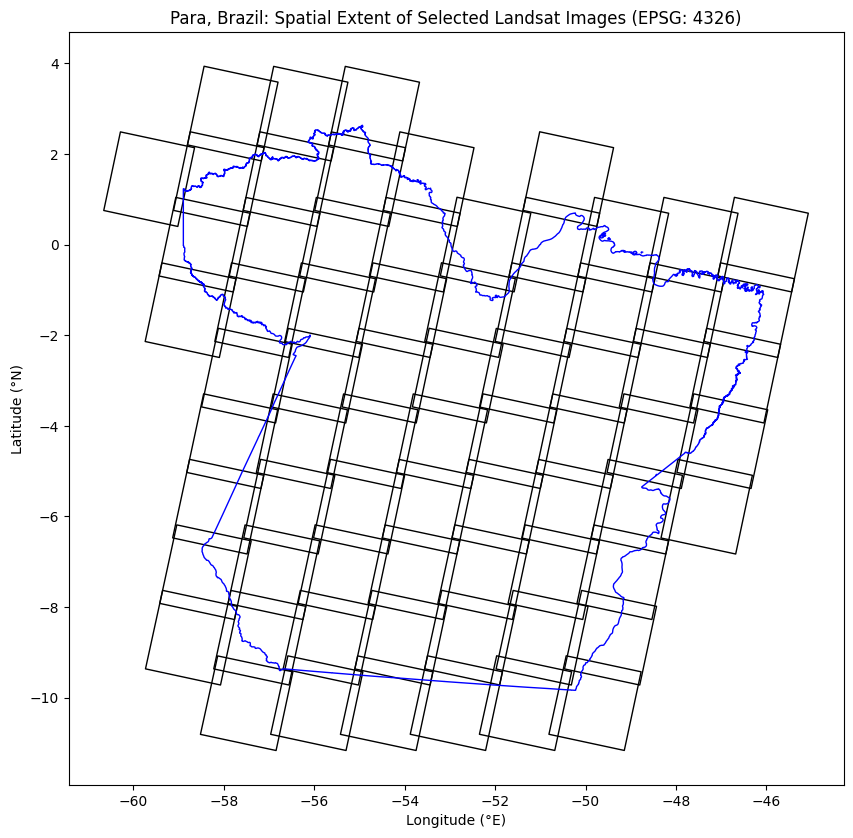

In [15]:
fig, ax = plt.subplots(figsize=(10,10))

lowest_cloud.plot(ax=ax, color='none')
para.plot(ax=ax, color='none', edgecolor='blue')

ax.set_title('Para, Brazil: Spatial Extent of Selected Landsat Images (EPSG: 4326)')
ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')

plt.show()

In [16]:
lowest_cloud.explore()

## Selecting the Chosen Items
### Creating a Dictionary of Chosen Items

In [17]:
item_dict = {item.id: item for item in items}

### Mapping the Dictionary to the Lowest Cloud GeoDataFrame

In [18]:
lowest_cloud['item'] = lowest_cloud['id'].map(item_dict)
lowest_cloud.head()

,geometry,platform,instruments,created,gsd,description,eo:cloud_cover,view:off_nadir,view:sun_elevation,view:sun_azimuth,...,landsat:product_generated,grid:code,sci:doi,datetime,earthsearch:payload_id,processing:software,updated,proj:code,id,item
1704,"POLYGON ((-56.58345 -9.08029, -56.96437 -10.81...",landsat-8,"[oli, tirs]",2024-07-06T05:15:53.650Z,30,Landsat Collection 2 Level-2,0.0,0,46.084975,39.837255,...,2024-07-06T04:32:32Z,WRS2-227067,10.5066/P9OGBGM6,2024-06-19T13:49:24.619890Z,usgs-landsat-c2l2/workflow-landsat-to-stac/0c2...,{'landsat-to-stac': 'v2023.11.16'},2024-07-06T05:15:53.650Z,EPSG:32621,LC08_L2SP_227067_20240619_02_T1,<Item id=LC08_L2SP_227067_20240619_02_T1>
1292,"POLYGON ((-58.13621 -9.08174, -58.51756 -10.81...",landsat-9,"[oli, tirs]",2024-08-06T12:25:51.562Z,30,Landsat Collection 2 Level-2,0.0,0,49.975599,48.137342,...,2024-08-06T11:54:14Z,WRS2-228067,10.5066/P9OGBGM6,2024-08-05T13:55:54.265566Z,usgs-landsat-c2l2/workflow-landsat-to-stac/7b3...,{'landsat-to-stac': 'v2023.11.16'},2024-08-06T12:25:51.562Z,EPSG:32621,LC09_L2SP_228067_20240805_02_T1,<Item id=LC09_L2SP_228067_20240805_02_T1>
1680,"POLYGON ((-51.60061 -7.63674, -51.97787 -9.369...",landsat-9,"[oli, tirs]",2024-06-23T11:52:39.614Z,30,Landsat Collection 2 Level-2,0.0,0,47.216646,40.792711,...,2024-06-23T11:34:52Z,WRS2-224066,10.5066/P9OGBGM6,2024-06-22T13:30:18.286999Z,usgs-landsat-c2l2/workflow-landsat-to-stac/ba4...,{'landsat-to-stac': 'v2023.11.16'},2024-06-23T11:52:39.614Z,EPSG:32622,LC09_L2SP_224066_20240622_02_T1,<Item id=LC09_L2SP_224066_20240622_02_T1>
1275,"POLYGON ((-55.03971 -9.08123, -55.42108 -10.81...",landsat-9,"[oli, tirs]",2024-08-08T15:17:15.122Z,30,Landsat Collection 2 Level-2,0.0,0,50.378905,48.742798,...,2024-08-08T11:14:21Z,WRS2-226067,10.5066/P9OGBGM6,2024-08-07T13:43:32.326404Z,usgs-landsat-c2l2/workflow-landsat-to-stac/0d6...,{'landsat-to-stac': 'v2023.11.16'},2024-08-08T15:17:15.122Z,EPSG:32621,LC09_L2SP_226067_20240807_02_T1,<Item id=LC09_L2SP_226067_20240807_02_T1>
1276,"POLYGON ((-54.72427 -7.63631, -55.10257 -9.368...",landsat-9,"[oli, tirs]",2024-08-08T15:16:26.821Z,30,Landsat Collection 2 Level-2,0.0,0,51.480788,49.888905,...,2024-08-08T11:14:38Z,WRS2-226066,10.5066/P9OGBGM6,2024-08-07T13:43:08.401500Z,usgs-landsat-c2l2/workflow-landsat-to-stac/b27...,{'landsat-to-stac': 'v2023.11.16'},2024-08-08T15:16:26.821Z,EPSG:32621,LC09_L2SP_226066_20240807_02_T1,<Item id=LC09_L2SP_226066_20240807_02_T1>


## Inspecting a Single Item
### Item Properties

In [19]:
item = lowest_cloud['item'].iloc[0]
item

<Item id=LC08_L2SP_227067_20240619_02_T1>

### Item Assets

In [20]:
assets = item.assets
assets

{'thumbnail': <Asset href=s3://usgs-landsat/collection02/level-2/standard/oli-tirs/2024/227/067/LC08_L2SP_227067_20240619_20240706_02_T1/LC08_L2SP_227067_20240619_20240706_02_T1_thumb_small.jpeg>,
 'reduced_resolution_browse': <Asset href=s3://usgs-landsat/collection02/level-2/standard/oli-tirs/2024/227/067/LC08_L2SP_227067_20240619_20240706_02_T1/LC08_L2SP_227067_20240619_20240706_02_T1_thumb_large.jpeg>,
 'mtl.json': <Asset href=s3://usgs-landsat/collection02/level-2/standard/oli-tirs/2024/227/067/LC08_L2SP_227067_20240619_20240706_02_T1/LC08_L2SP_227067_20240619_20240706_02_T1_MTL.json>,
 'mtl.txt': <Asset href=s3://usgs-landsat/collection02/level-2/standard/oli-tirs/2024/227/067/LC08_L2SP_227067_20240619_20240706_02_T1/LC08_L2SP_227067_20240619_20240706_02_T1_MTL.txt>,
 'mtl.xml': <Asset href=s3://usgs-landsat/collection02/level-2/standard/oli-tirs/2024/227/067/LC08_L2SP_227067_20240619_20240706_02_T1/LC08_L2SP_227067_20240619_20240706_02_T1_MTL.xml>,
 'ang': <Asset href=s3://usgs-

## Exporting Results 
### Exporting Selected Landsat Scene Names for USGS Bulk Download

In [21]:
landsat_scene_ids = lowest_cloud[['landsat:scene_id']]
landsat_scene_ids = landsat_scene_ids.rename(columns={'landsat:scene_id': '#LANDSAT_8_C2_L2|ENTITY_ID'})

landsat_scene_ids.to_csv('landsat_scene_ids.csv', index=False)

### Exporting RGB Landsat Scenes from Downloaded USGS Data

In [22]:
base = Path('para')
outputs_folder = Path('outputs')
outputs_folder.mkdir(exist_ok=True)

folders = [
    folder
    for folder in base.iterdir()
    if folder.is_dir()
]

for folder in folders:
    band_map = {
        'red': 'B4.TIF',
        'green': 'B3.TIF',
        'blue': 'B2.TIF',
        'qa_pixel': '_QA_PIXEL.TIF'
    }

    bands = {
        band: next(
            rxr.open_rasterio(file, masked=True).squeeze(drop=True)
            for file in folder.iterdir()
            if file.is_file() and file.name.endswith(suffix)
        )
        
        for band, suffix in band_map.items()
    }

    for name, data in bands.items():
        if name == 'qa_pixel':
            data = data.fillna(0).astype('uint16')
            resampling = Resampling.nearest
        else:
            resampling = Resampling.bilinear

        data = data.rio.reproject('EPSG:31982', resampling=resampling)
        bands[name] = data

    qa = bands['qa_pixel']

    fill = ((qa >> 0) & 1)
    clear = ((qa >> 6) & 1)

    cloud_mask = (clear == 0).astype('int16')
    cloud_mask = cloud_mask.where(fill == 0)
    
    bands.pop('qa_pixel')
    bands['cloud_mask'] = cloud_mask

    for name, data in bands.items():
        data = data.fillna(-9999).astype('int16')
        data = data.rio.write_nodata(-9999)
    
        bands[name] = data

    rgb = xr.Dataset({
        name: data
        for name, data in bands.items()
    })

    rgb_file_path = outputs_folder/ f'{folder.name}.tif'
    rgb.rio.to_raster(
        rgb_file_path,
        descriptions=['red', 'green', 'blue', 'cloud_mask']
    )

    print(f'Exported {rgb_file_path.name}')

Exported LC08_L2SP_227062_20241110_20241118_02_T1.tif
Exported LC08_L2SP_225067_20240707_20240718_02_T1.tif
Exported LC08_L2SP_229063_20240719_20240723_02_T1.tif
Exported LC08_L2SP_223063_20240826_20240831_02_T1.tif
Exported LC08_L2SP_229065_20240617_20240705_02_T1.tif
Exported LC08_L2SP_227065_20240721_20240723_02_T1.tif
Exported LC09_L2SP_227059_20240814_20240815_02_T1.tif
Exported LC09_L2SP_224061_20240825_20240826_02_T1.tif
Exported LC08_L2SP_222063_20240803_20240808_02_T1.tif
Exported LC09_L2SP_226065_20240722_20240723_02_T1.tif
Exported LC09_L2SP_224062_20240825_20240826_02_T1.tif
Exported LC09_L2SP_228063_20240720_20240721_02_T1.tif
Exported LC09_L2SP_223065_20240717_20240718_02_T1.tif
Exported LC09_L2SP_226067_20240807_20240808_02_T1.tif
Exported LC09_L2SP_228058_20240922_20240924_02_T1.tif
Exported LC09_L2SP_227060_20241102_20241103_02_T1.tif
Exported LC09_L2SP_230061_20240819_20240820_02_T1.tif
Exported LC08_L2SP_227061_20241110_20241118_02_T1.tif
Exported LC08_L2SP_223067_20